In [1]:
import pycaret
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pycaret.classification import *
from sklearn.decomposition import PCA

Loading data and generating EDA plots...


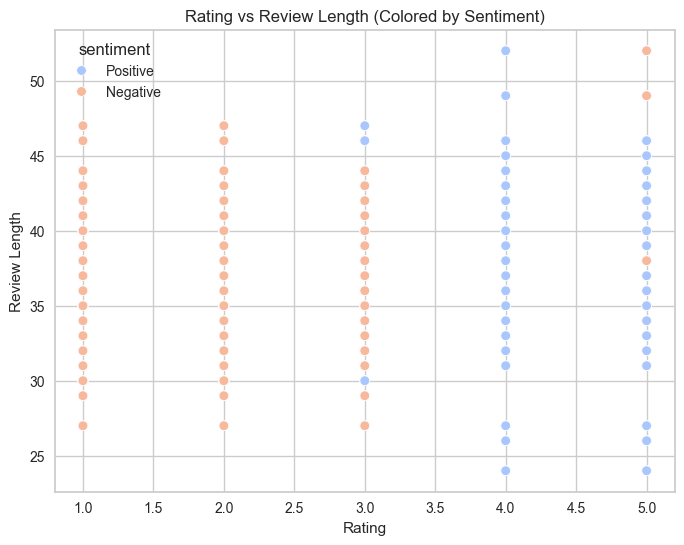

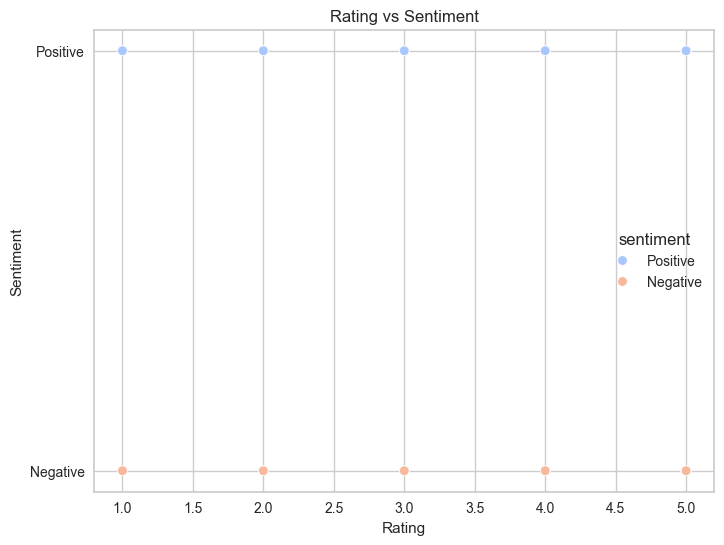

In [54]:
# Phase 1: Data Loading & EDA

print("Loading data and generating EDA plots...")
df = pd.read_csv('realistic_high_accuracy_sentiment_dataset.csv')

# Create 'review_length' feature
df['review_length'] = df['review_text'].apply(len)

# Plot 1: Rating vs Review Length
plt.figure(figsize=(8, 6))
sns.scatterplot(x='rating', y='review_length', data=df, hue='sentiment', palette='coolwarm')
plt.title('Rating vs Review Length (Colored by Sentiment)')
plt.xlabel('Rating')
plt.ylabel('Review Length')
plt.show()

# Plot 2: Rating vs Sentiment
plt.figure(figsize=(8, 6))
sns.scatterplot(x='rating', y='sentiment', data=df, hue='sentiment', palette='coolwarm')
plt.title('Rating vs Sentiment')
plt.xlabel('Rating')
plt.ylabel('Sentiment')
plt.show()

In [ ]:
# Phase 2: PyCaret Setup & Base Training

print("Setting up PyCaret and finding the best base model...")
clf = setup(
    data=df,
    target='sentiment',
    text_features=['review_text'],
    train_size=0.8,
    session_id=42
)

best_model = compare_models()



# Phase 3: Hyperparameter Tuning (NEW)
print("Starting hyperparameter tuning. This might take a moment...")
tuned_model = tune_model(best_model, optimize='Accuracy', n_iter=10)
evaluate_model(tuned_model)

Setting up PyCaret and finding the best base model...


,Description,Value
0,Session id,42
1,Target,sentiment
2,Target type,Binary
3,Target mapping,"Negative: 0, Positive: 1"
4,Original data shape,"(6000, 9)"
5,Transformed data shape,"(6000, 72)"
6,Transformed train set shape,"(4800, 72)"
7,Transformed test set shape,"(1200, 72)"
8,Numeric features,2
9,Text features,1


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.9781,0.9777,0.9781,0.9782,0.9781,0.9562,0.9563,0.2290
nb,Naive Bayes,0.9781,0.9742,0.9781,0.9782,0.9781,0.9562,0.9563,0.0200
ridge,Ridge Classifier,0.9781,0.9783,0.9781,0.9782,0.9781,0.9562,0.9563,0.0190
knn,K Neighbors Classifier,0.9758,0.9786,0.9758,0.9759,0.9758,0.9517,0.9517,0.1850
svm,SVM - Linear Kernel,0.9421,0.9773,0.9421,0.9458,0.9419,0.8842,0.8879,0.0220
et,Extra Trees Classifier,0.9325,0.9773,0.9325,0.9383,0.9321,0.8650,0.8707,0.0390
rf,Random Forest Classifier,0.5004,0.9759,0.5004,0.3501,0.3343,0.0008,0.0091,0.0430
dt,Decision Tree Classifier,0.5000,0.5000,0.5000,0.2500,0.3333,0.0000,0.0000,0.0220
qda,Quadratic Discriminant Analysis,0.5000,0.4780,0.5000,0.2500,0.3333,0.0000,0.0000,0.0210
ada,Ada Boost Classifier,0.5000,0.5000,0.5000,0.2500,0.3333,0.0000,0.0000,0.0200


Starting hyperparameter tuning. This might take a moment...


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9833,0.9842,0.9833,0.9834,0.9833,0.9667,0.9667
1,0.9708,0.9633,0.9708,0.9709,0.9708,0.9417,0.9417
2,0.9812,0.9778,0.9812,0.9813,0.9812,0.9625,0.9625
3,0.9812,0.9802,0.9812,0.9813,0.9812,0.9625,0.9625
4,0.9729,0.9746,0.9729,0.9731,0.9729,0.9458,0.9460
5,0.9604,0.9579,0.9604,0.9605,0.9604,0.9208,0.9209
6,0.9896,0.9935,0.9896,0.9897,0.9896,0.9792,0.9792
7,0.9771,0.9816,0.9771,0.9771,0.9771,0.9542,0.9542
8,0.9792,0.9814,0.9792,0.9792,0.9792,0.9583,0.9584


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Generating PCA scatter plot...


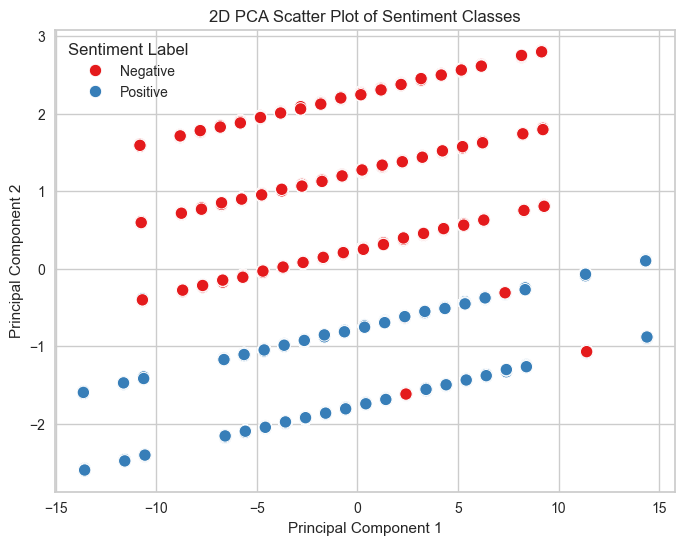

In [ ]:
# Phase 4: PCA Dimensionality Reduction
print("Generating PCA scatter plot...")

X = get_config('X')
y = get_config('y')

X_encoded = pd.get_dummies(X, columns=X.select_dtypes(include=['object', 'category']).columns)

#Reduce dimensions to 2D using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_encoded)

#2D PCA Scatter Plot
scatter_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
scatter_df['Sentiment Label'] = y.values

plt.figure(figsize=(8, 6))
sns.scatterplot(data=scatter_df, x='PC1', y='PC2', hue='Sentiment Label', palette='Set1', s=80)
plt.title('2D PCA Scatter Plot of Sentiment Classes')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

In [57]:
# Phase 5: Automated PyCaret Visualizations
print("Starting to generate and save PyCaret plots for the tuned model...")

plots_to_generate = {
    'auc': 'ROC Curve',
    'confusion_matrix': 'Confusion Matrix',
    'pr': 'Precision-Recall Curve',
    'learning': 'Learning Curve',
    'feature': 'Feature Importance',
    'class_report': 'Classification Report',
    'boundary': 'Decision Boundary',
    'calibration': 'Calibration Curve',
    'vc': 'Validation Curve',
    'error': 'Error Plot',
    'manifold': 'Manifold Learning Plot',
    'parameter': 'Hyperparameter Tuning Plot',
    'lift': 'Lift Curve',
    'gain': 'Gain Curve',
    'ks': 'KS Statistic Plot'
}

# Loop through and safely save each plot using the tuned_model
for plot_id, plot_name in plots_to_generate.items():
    print(f"Generating {plot_name}...")
    try:
        plot_model(tuned_model, plot=plot_id, save=True)
        print(" -> Successfully saved.")
    except Exception as e:
        print(f" -> Skipped (Incompatible with model). Reason: {e}")

print("All step-by-step plotting and tuning completed!")

Starting to generate and save PyCaret plots for the tuned model...
Generating ROC Curve...


 -> Successfully saved.
Generating Confusion Matrix...


 -> Successfully saved.
Generating Precision-Recall Curve...


 -> Successfully saved.
Generating Learning Curve...


 -> Successfully saved.
Generating Feature Importance...


...

,Parameters
C,1.0
class_weight,None
dual,False
fit_intercept,True
intercept_scaling,1
l1_ratio,None
max_iter,1000
multi_class,auto
n_jobs,None
penalty,l2


 -> Successfully saved.
Generating Lift Curve...


 -> Successfully saved.
Generating Gain Curve...


 -> Successfully saved.
Generating KS Statistic Plot...


 -> Successfully saved.
All step-by-step plotting and tuning completed!
